<a href="https://colab.research.google.com/github/rally-adty/UNSIA-Data-Sciense-SM-4/blob/main/Pertemuan4_M_Rally_Adityo_240401010212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = sns.load_dataset('iris')

In [3]:
print(df.shape)

(150, 5)


In [4]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.describe().round(3)

,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [7]:
for col_name in df.select_dtypes(include='number').columns:

    col = df[col_name]

    print(f'\n=== {col_name} ===')

    print(f'Mean : {col.mean():.3f}')

    print(f'Median : {col.median():.3f}')

    print(f'Std Dev : {col.std():.3f}')

    print(f'Varians : {col.var():.3f}')

    print(f'Skewness : {col.skew():.3f}')

    print(f'Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
Mean : 5.843
Median : 5.800
Std Dev : 0.828
Varians : 0.686
Skewness : 0.315
Kurtosis : -0.552

=== sepal_width ===
Mean : 3.057
Median : 3.000
Std Dev : 0.436
Varians : 0.190
Skewness : 0.319
Kurtosis : 0.228

=== petal_length ===
Mean : 3.758
Median : 4.350
Std Dev : 1.765
Varians : 3.116
Skewness : -0.275
Kurtosis : -1.402

=== petal_width ===
Mean : 1.199
Median : 1.300
Std Dev : 0.762
Varians : 0.581
Skewness : -0.103
Kurtosis : -1.341


In [8]:
col = df['sepal_length']

print("Mean :", col.mean())

print("Median :", col.median())

print("Modus :", col.mode()[0])

Mean : 5.843333333333334
Median : 5.8
Modus : 5.0


In [9]:
col = df['sepal_length']

print("Varians :", col.var())

print("Std Dev :", col.std())

Varians : 0.6856935123042505
Std Dev : 0.8280661279778629


In [10]:
Q1 = col.quantile(0.25)

Q2 = col.quantile(0.50)

Q3 = col.quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)

print("Q2 :", Q2)

print("Q3 :", Q3)

print("IQR :", IQR)

Q1 : 5.1
Q2 : 5.8
Q3 : 6.4
IQR : 1.3000000000000007


In [11]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = col[(col < lower) | (col > upper)]

print("Jumlah Outlier :", len(outliers))

Jumlah Outlier : 0


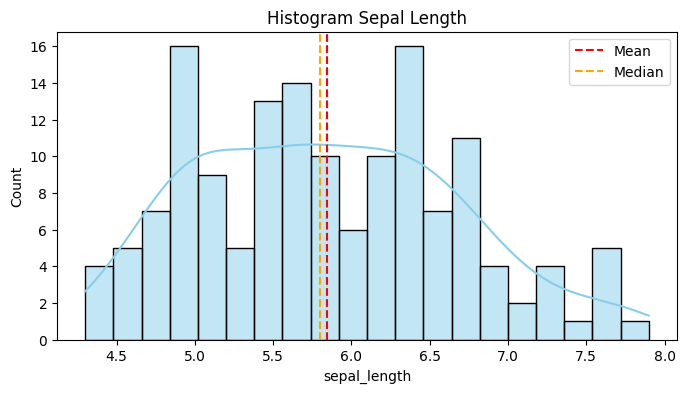

In [12]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='skyblue',
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label='Median'
)

ax.legend()

plt.title('Histogram Sepal Length')

plt.show()

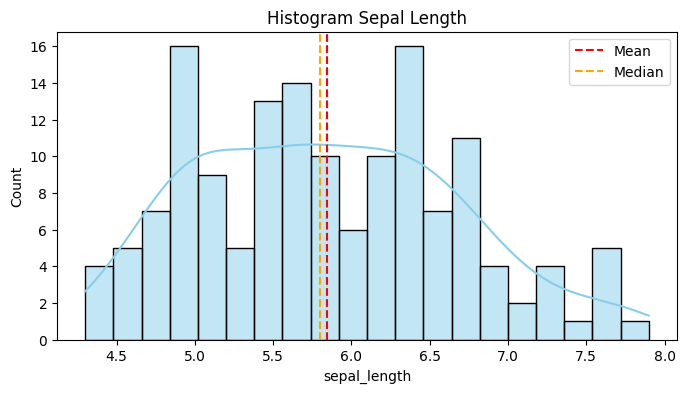

In [13]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='skyblue',
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label='Median'
)

ax.legend()

plt.title('Histogram Sepal Length')

plt.show()

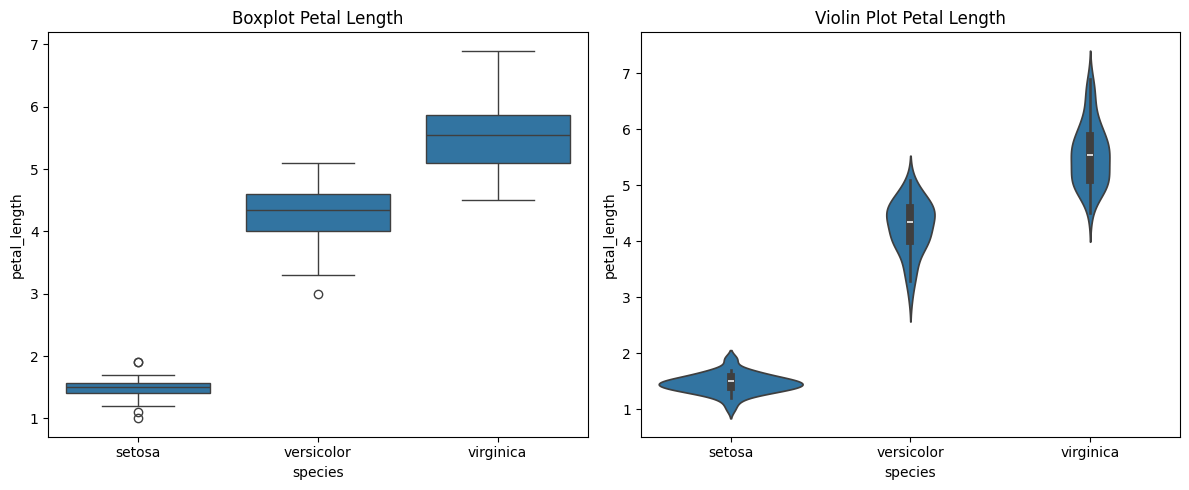

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()

plt.show()

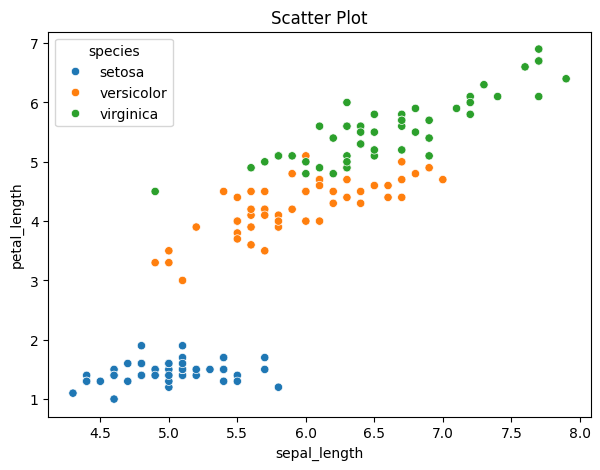

In [15]:
fig, ax = plt.subplots(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length',
    hue='species',
    ax=ax
)

plt.title('Scatter Plot')

plt.show()

In [16]:
corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [17]:
x = df['sepal_length']

y = df['petal_length']

# Pearson
r, p = stats.pearsonr(x, y)

print("Pearson r :", r)

# Spearman
rho, p2 = stats.spearmanr(x, y)

print("Spearman rho :", rho)

Pearson r : 0.8717537758865831
Spearman rho : 0.881898126434986


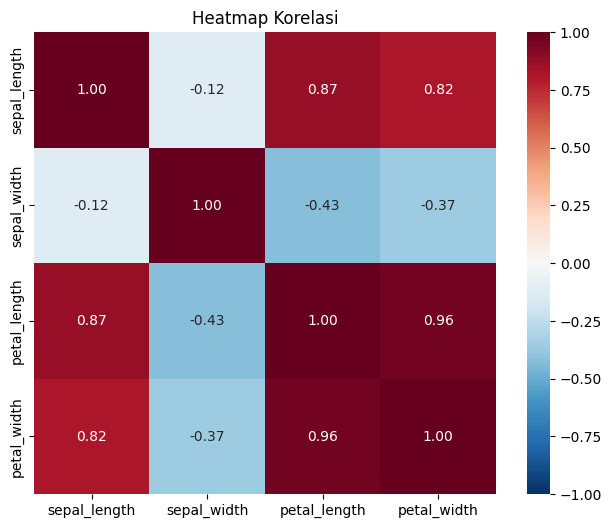

In [18]:
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax
)

plt.title('Heatmap Korelasi')

plt.show()

In [19]:
mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(max_pair)

print(corr.loc[max_pair])

('petal_width', 'petal_length')
0.962865431402796


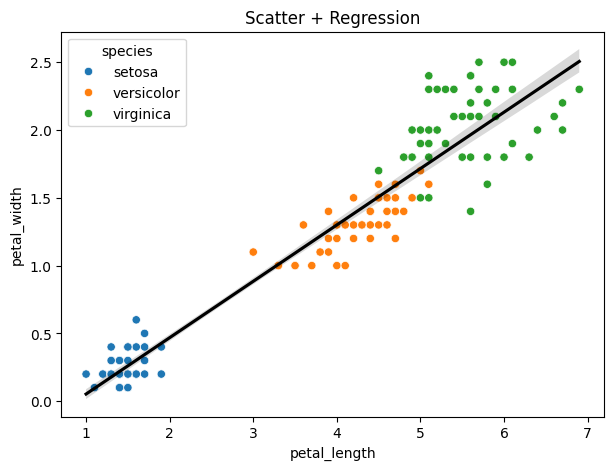

In [20]:
fig, ax = plt.subplots(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    ax=ax
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='black',
    ax=ax
)

plt.title('Scatter + Regression')

plt.show()

Kesimpulan:
- Dataset iris memiliki korelasi kuat antara petal_length dan petal_width.
- Distribusi sepal_length mendekati normal.
- Species virginica memiliki petal_length terbesar.
- Heatmap menunjukkan korelasi positif kuat antar fitur petal.